In [251]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rajyellow46/wine-quality/winequalityN.csv


In [252]:
df = pd.read_csv("/kaggle/input/datasets/rajyellow46/wine-quality/winequalityN.csv")

In [253]:
df

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,white,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,white,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,white,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,red,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
6493,red,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,NaN,11.2,6
6494,red,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
6495,red,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [254]:
df.shape

(6497, 13)

In [255]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [256]:
df.isnull().sum()

type                     0
fixed acidity           10
volatile acidity         8
citric acid              3
residual sugar           2
chlorides                2
free sulfur dioxide      0
total sulfur dioxide     0
density                  0
pH                       9
sulphates                4
alcohol                  0
quality                  0
dtype: int64

In [257]:
df.shape

(6497, 13)

In [258]:

# from sklearn.preprocessing import OneHotEncoder


# encoder = OneHotEncoder(sparse_output=False)
# encoded = encoder.fit_transform(df[['type']])
# encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['type']))

# df = pd.concat([df.drop(columns=['type']), encoded_df], axis=1)


In [259]:
# df.head()

In [260]:
X = df.drop(columns=['quality', 'type']) 
y = df['quality']  

we removed wine type from the dataset as it is highly corelated with the target columns

In [261]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X,y , test_size = 0.2 , random_state = 42)

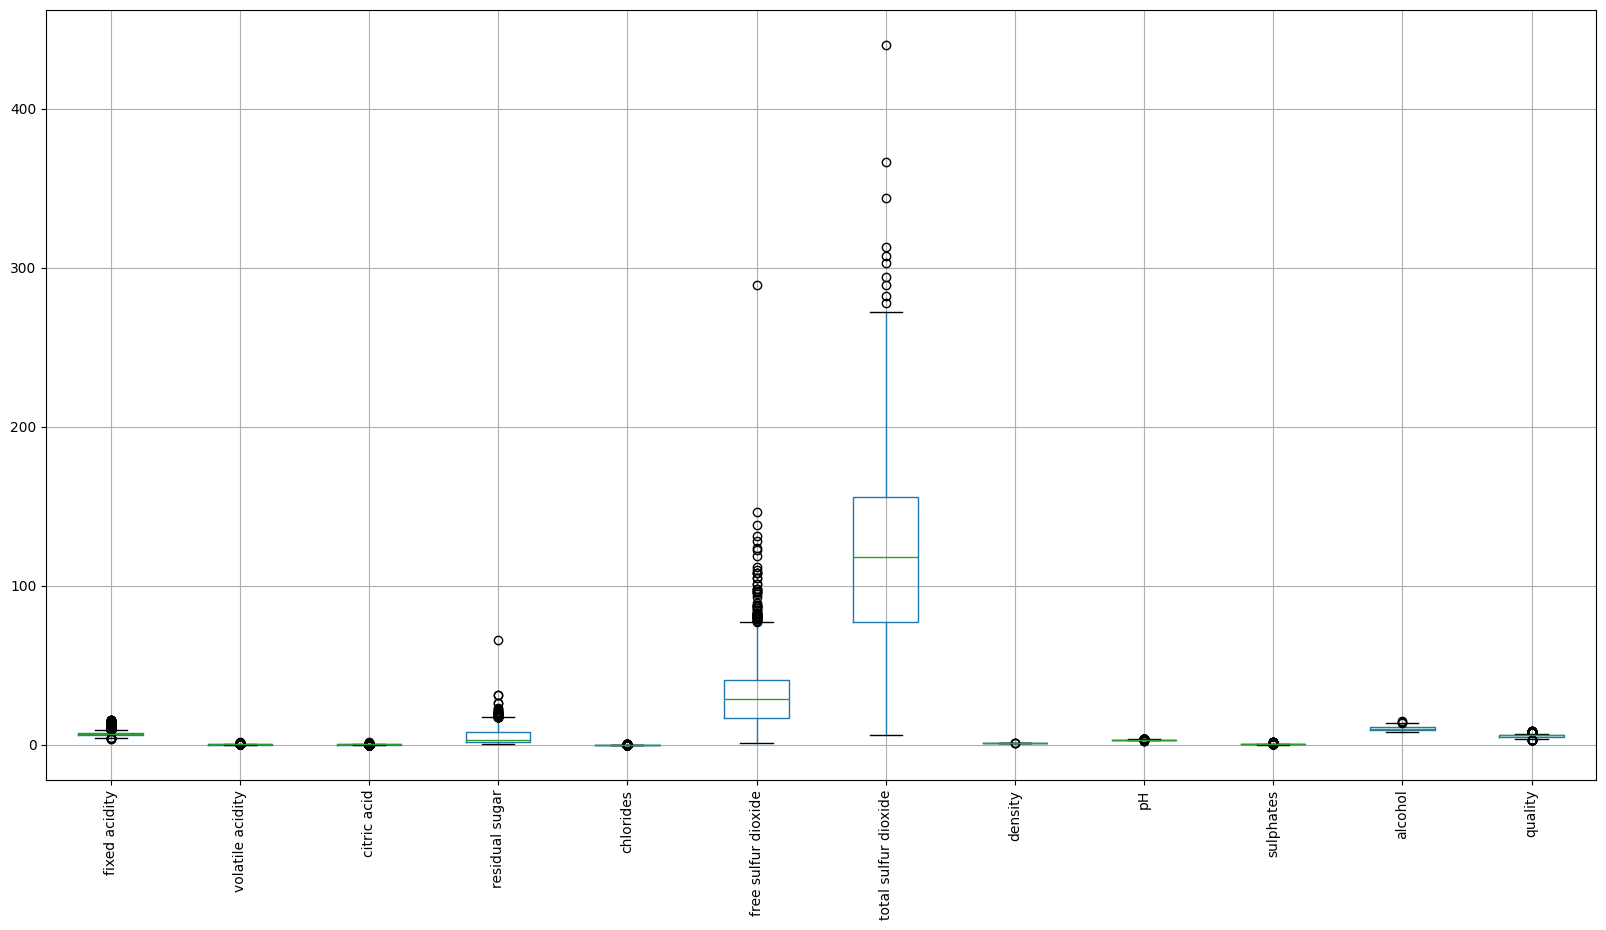

In [262]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 10))
df.boxplot()
plt.xticks(rotation=90)
plt.show()

we have lots of outlier but our main goal right now is to practise classifiaction metrices so we are not going to do anything about it .


In [263]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


**handling missing values**

In [264]:
from sklearn.impute import SimpleImputer

cols_to_impute = ['fixed acidity', 'volatile acidity', 'citric acid', 
                  'residual sugar', 'chlorides', 'pH', 'sulphates']

imputer = SimpleImputer(strategy='mean')

X_train[cols_to_impute] = imputer.fit_transform(X_train[cols_to_impute])
X_test[cols_to_impute] = imputer.transform(X_test[cols_to_impute])

In [265]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [266]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train,y_train)
y_pred1 = lr.predict(X_test)

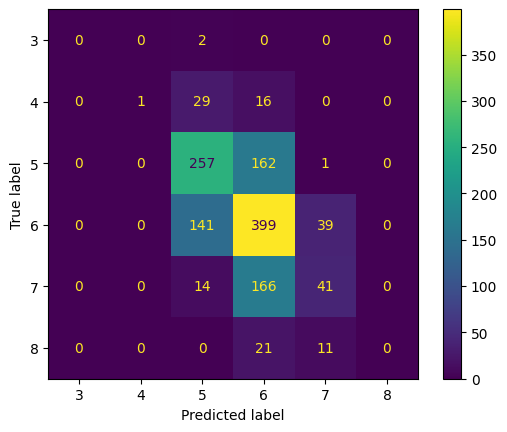

In [267]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred1)
plt.show()

In [268]:
print(y.value_counts())

quality
6    2836
5    2138
7    1079
4     216
8     193
3      30
9       5
Name: count, dtype: int64


In [269]:
from sklearn.metrics import precision_score , recall_score , f1_score , accuracy_score

print("accuracy is " , accuracy_score(y_test, y_pred1))
print('precision is ', precision_score(y_test, y_pred1, average=None , zero_division=0))
print('Recall is ' , recall_score(y_test , y_pred1 , average = None , zero_division=0) )
print('F1 score  is ' , f1_score(y_test , y_pred1 , average = None , zero_division=0) )


accuracy is  0.536923076923077
precision is  [0.         1.         0.58013544 0.52225131 0.44565217 0.        ]
Recall is  [0.         0.02173913 0.61190476 0.68911917 0.18552036 0.        ]
F1 score  is  [0.         0.04255319 0.59559676 0.59419211 0.26198083 0.        ]


In [270]:
print('precision is ', precision_score(y_test, y_pred1, average='weighted' , zero_division=0))
print('Recall is ' , recall_score(y_test , y_pred1 , average ='weighted' , zero_division=0) )
print('F1 score  is ' , f1_score(y_test , y_pred1 , average = 'weighted' , zero_division=0) )

precision is  0.5311765562800248
Recall is  0.536923076923077
F1 score  is  0.5031100598310732


In [271]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train , y_train)
y_pred2 = rf.predict(X_test)

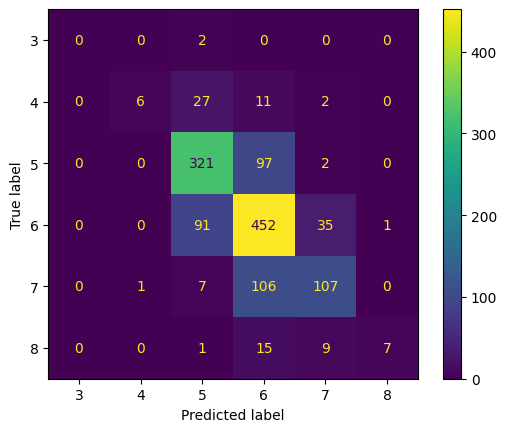

In [272]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred2)
plt.show()

In [273]:
print("accuracy is " , accuracy_score(y_test, y_pred2))
print('precision is ', precision_score(y_test, y_pred2, average='weighted' , zero_division=0))
print('Recall is ' , recall_score(y_test , y_pred2 , average ='weighted' , zero_division=0) )
print('F1 score  is ' , f1_score(y_test , y_pred2 , average = 'weighted' , zero_division=0) )

accuracy is  0.686923076923077
precision is  0.6958128321550633
Recall is  0.686923076923077
F1 score  is  0.671610938491778


In [274]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred1, zero_division=0))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       1.00      0.02      0.04        46
           5       0.58      0.61      0.60       420
           6       0.52      0.69      0.59       579
           7       0.45      0.19      0.26       221
           8       0.00      0.00      0.00        32

    accuracy                           0.54      1300
   macro avg       0.42      0.25      0.25      1300
weighted avg       0.53      0.54      0.50      1300



In [275]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred2, zero_division=0))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.86      0.13      0.23        46
           5       0.71      0.76      0.74       420
           6       0.66      0.78      0.72       579
           7       0.69      0.48      0.57       221
           8       0.88      0.22      0.35        32

    accuracy                           0.69      1300
   macro avg       0.63      0.40      0.43      1300
weighted avg       0.70      0.69      0.67      1300

